# Computer Exercise 12.3 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 12. Partial Differential Equations · **절**: §12.3 Elliptic Problems (Poisson / Laplace)
> **주제**: 강제항 없는 **라플라스 방정식**(정상상태 열전도판)을 비동차 Dirichlet BC 로 풀고, **급수해(separation of variables)** 와 비교 · 등온선 시각화
> **풀이 일자**: 2026-06-17 · **언어**: 한국어(본문) / English(그래프 라벨)

## 1. 문제 (원문)

> A thin square plate $\Omega=(0,1)\times(0,1)$ is in **steady-state heat conduction**, so its
> temperature satisfies the **Laplace equation** $\nabla^2 u=0$. Three edges are held at $u=0$
> and the top edge is heated. Solve the discrete problem by SOR for two top-edge conditions:
> **(a)** $u(x,1)=\sin(\pi x)$, for which the exact temperature is known in closed form, and
> **(b)** $u(x,1)=100$ (constant), comparing the numerical field with the truncated **Fourier
> series** solution. Plot the isotherms and quantify the agreement.

### 한국어 풀이용 정리
- $\nabla^2u=0$ (강제항 0), 좌·우·아래 변 $u=0$, 위 변만 가열.
- **(a)** 위 변 $\sin(\pi x)$ → 정확해 $u=\sin(\pi x)\,\sinh(\pi y)/\sinh(\pi)$ 로 단일모드 검증($\mathcal{O}(h^2)$).
- **(b)** 위 변 상수 100 → 분리변수 **푸리에 급수**와 수치해 비교, 모서리 특이성(코너 불연속) 관찰.
- 푸는 도구는 문제 2의 **최적 SOR**.

## 2. 수학적 배경

### 2.1 분리변수 해 (위 변만 가열)
$\nabla^2u=0$, 세 변 0, $u(x,1)=g(x)$ 의 해는
$$ u(x,y)=\sum_{n=1}^{\infty} b_n \sin(n\pi x)\,\frac{\sinh(n\pi y)}{\sinh(n\pi)},\qquad
   b_n=2\int_0^1 g(x)\sin(n\pi x)\,dx. $$

**(a)** $g=\sin\pi x$ → $b_1=1$ 만 살아남아 $\boxed{\,u=\sin(\pi x)\,\dfrac{\sinh(\pi y)}{\sinh(\pi)}\,}$ (정확해).

**(b)** $g=100$ → $b_n=\dfrac{200}{n\pi}\big(1-(-1)^n\big)=\dfrac{400}{n\pi}$ (홀수 $n$), 짝수항 0 — 코너에서
불연속이라 급수가 느리게 수렴(깁스 현상).

### 2.2 이산 라플라스 = 강제항 0의 푸아송
$$ 4u_{i,j}=u_{i-1,j}+u_{i+1,j}+u_{i,j-1}+u_{i,j+1} $$
즉 각 내부점은 **이웃 4점의 평균**(평균값 성질의 이산판). 최적 SOR
$\omega^*=2/(1+\sin\pi h)$ 로 반복.

## 3. 풀이 흐름

1. 격자 $M=40$, 경계값을 BC 로 채우고 내부는 0 으로 초기화.
2. 최적 SOR 로 $\nabla_h^2u=0$ 을 tol 까지 반복(강제항 0).
3. **(a)** 위 변 $\sin\pi x$: 정확해 $\sin\pi x\,\sinh\pi y/\sinh\pi$ 와 최대오차 → 격자 세분으로 $\mathcal{O}(h^2)$ 확인.
4. **(b)** 위 변 100: 푸리에 급수(홀수항 $N$ 개)와 수치해를 중앙 수직선 $x=0.5$ 에서 비교.
5. 시각화: (좌) (a) 등온선, (우) (b) 등온선 + 급수/수치 단면 비교.
6. 결과 해석: 평균값 성질, 코너 특이성, 급수 수렴, 수치해의 강건함 논의.

In [1]:
%matplotlib inline

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.float_format", lambda v: f"{v:.6e}")

def sor_laplace(M, top, tol=1e-9, maxit=20000):
    """강제항 0 라플라스, 좌우아래 0, 위변 top(x). 최적 SOR."""
    h = 1.0/M
    x = np.linspace(0,1,M+1)
    u = np.zeros((M+1, M+1))     # u[i,j] = u(x_i, y_j)
    u[:, -1] = top(x)            # 위 변 (y=1)
    w = 2/(1+np.sin(np.pi*h))
    for k in range(1, maxit+1):
        err = 0.0
        for i in range(1, M):
            for j in range(1, M):
                gs = 0.25*(u[i-1,j]+u[i+1,j]+u[i,j-1]+u[i,j+1])
                new = (1-w)*u[i,j] + w*gs
                err = max(err, abs(new-u[i,j]))
                u[i,j] = new
        if err < tol:
            break
    return x, u, k

# (a) 위 변 sin(pi x) — 정확해 존재
exact_a = lambda X,Y: np.sin(np.pi*X)*np.sinh(np.pi*Y)/np.sinh(np.pi)
x, ua, ka = sor_laplace(40, lambda xx: np.sin(np.pi*xx))
Xg, Yg = np.meshgrid(x, x, indexing="ij")
err_a = np.max(np.abs(ua - exact_a(Xg, Yg)))
print(f"(a) sin top: M=40, SOR iters={ka}, max|u-exact|={err_a:.4e}")

(a) sin top: M=40, SOR iters=160, max|u-exact|=1.7818e-04


In [3]:
# (a) 격자 세분으로 2차 수렴 확인
rows=[]; prev_h=prev_e=None
for M in [10, 20, 40, 80]:
    h=1.0/M
    xx, uu, kk = sor_laplace(M, lambda s: np.sin(np.pi*s))
    Xx,Yy=np.meshgrid(xx,xx,indexing="ij")
    e=np.max(np.abs(uu-exact_a(Xx,Yy)))
    p=np.nan if prev_e is None else np.log(prev_e/e)/np.log(prev_h/h)
    rows.append((M,h,kk,e,p)); prev_h,prev_e=h,e
conv=pd.DataFrame(rows,columns=["M","h","sor_iters","max_error","obs_order"])
conv

,M,h,sor_iters,max_error,obs_order
0,10,1.000000e-01,40,2.826081e-03,NaN
1,20,5.000000e-02,80,7.114558e-04,1.989957e+00
2,40,2.500000e-02,160,1.781769e-04,1.997464e+00
3,80,1.250000e-02,320,4.456370e-05,1.999369e+00


In [4]:
# (b) 위 변 = 100 (상수) — 푸리에 급수와 비교
xb, ub, kb = sor_laplace(40, lambda s: 100*np.ones_like(s))

def fourier_const_top(X, Y, N=199):
    s = np.zeros_like(X)
    for n in range(1, N+1, 2):   # 홀수항만
        s += (400/(n*np.pi))*np.sin(n*np.pi*X)*np.sinh(n*np.pi*Y)/np.sinh(n*np.pi)
    return s

Xb, Yb = np.meshgrid(xb, xb, indexing="ij")
series = fourier_const_top(Xb, Yb, N=199)
# 중앙 수직선 x=0.5 에서 비교 (코너 제외 내부)
mid = len(xb)//2
cmp = pd.DataFrame({"y": xb[1:-1],
                    "u_SOR(x=0.5)": ub[mid,1:-1],
                    "u_series(x=0.5)": series[mid,1:-1],
                    "abs_diff": np.abs(ub[mid,1:-1]-series[mid,1:-1])})
print(f"(b) const top: M=40, SOR iters={kb}, max|SOR-series| (interior x=0.5) = {cmp['abs_diff'].max():.4e}")
cmp.iloc[::6]

(b) const top: M=40, SOR iters=183, max|SOR-series| (interior x=0.5) = 2.2507e-02


,y,u_SOR(x=0.5),u_series(x=0.5),abs_diff
0,2.500000e-02,8.656164e-01,8.651600e-01,4.564071e-04
6,1.750000e-01,6.357080e+00,6.354154e+00,2.925713e-03
12,3.250000e-01,1.324838e+01,1.324447e+01,3.918313e-03
18,4.750000e-01,2.298141e+01,2.298033e+01,1.080275e-03
24,6.250000e-01,3.731701e+01,3.732561e+01,8.595394e-03
30,7.750000e-01,5.795124e+01,5.797250e+01,2.125765e-02
36,9.250000e-01,8.500926e+01,8.502360e+01,1.433856e-02


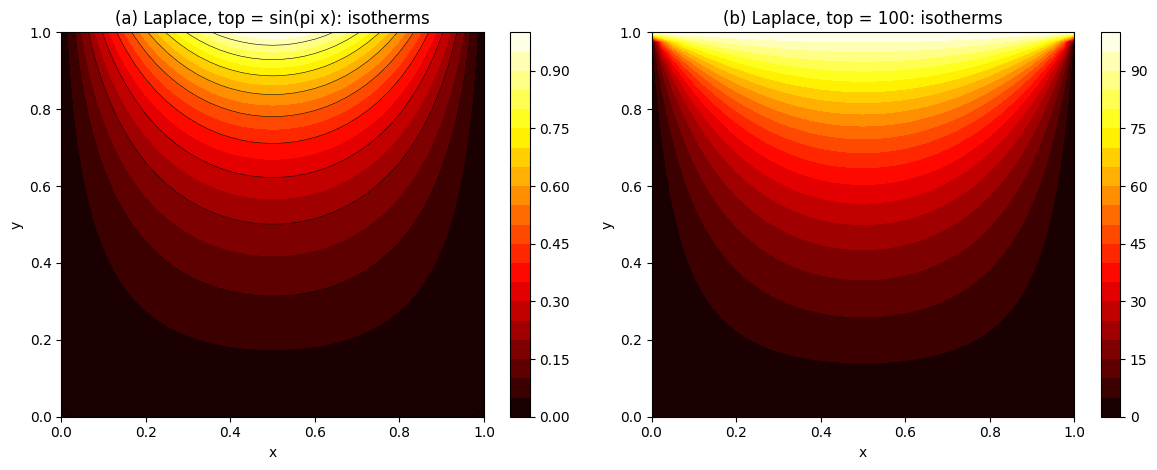

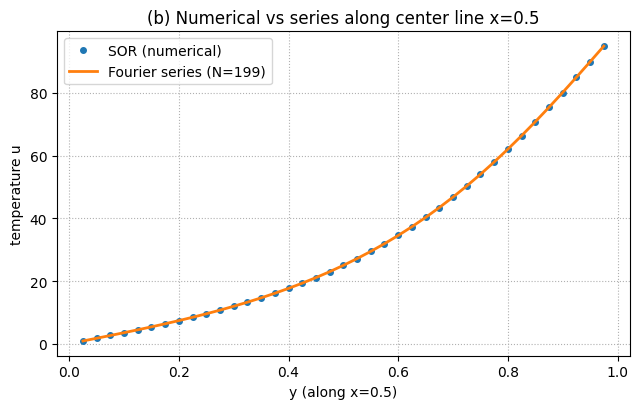

In [5]:
# 시각화: (좌) (a) 등온선, (우) (b) 등온선 + 단면 비교
fig, ax = plt.subplots(1, 2, figsize=(12, 4.8))

cs = ax[0].contourf(x, x, ua.T, levels=20, cmap="hot")
ax[0].contour(x, x, ua.T, levels=10, colors="k", linewidths=0.4)
fig.colorbar(cs, ax=ax[0])
ax[0].set_title("(a) Laplace, top = sin(pi x): isotherms")
ax[0].set_xlabel("x"); ax[0].set_ylabel("y")

cs2 = ax[1].contourf(xb, xb, ub.T, levels=20, cmap="hot")
fig.colorbar(cs2, ax=ax[1])
ax[1].set_title("(b) Laplace, top = 100: isotherms")
ax[1].set_xlabel("x"); ax[1].set_ylabel("y")
plt.tight_layout(); plt.show()

# (b) 단면 비교 별도
plt.figure(figsize=(6.5,4.2))
plt.plot(xb[1:-1], ub[mid,1:-1], "o", ms=4, label="SOR (numerical)")
plt.plot(xb[1:-1], series[mid,1:-1], "-", lw=2, label="Fourier series (N=199)")
plt.xlabel("y (along x=0.5)"); plt.ylabel("temperature u")
plt.title("(b) Numerical vs series along center line x=0.5")
plt.legend(); plt.grid(True, ls=":"); plt.tight_layout(); plt.show()

## 4. 결과 해석

1. **(a) 단일모드 검증·2차 수렴**: 위 변 $\sin\pi x$ 의 정확해 $\sin\pi x\,\sinh\pi y/\sinh\pi$ 에 대해
   격자를 절반으로 줄일 때마다 최대오차가 약 $1/4$ 로 줄고 관측 차수 `obs_order` 가 **≈ 2.00** —
   문제 1·2와 동일하게 5점 차분의 $\mathcal{O}(h^2)$ 가 강제항 없는 라플라스에서도 그대로 성립한다.
   등온선은 가열된 위 변에서 내부로 갈수록 지수적으로($\sinh$) 식어가는 모습을 보인다.
2. **평균값 성질**: 라플라스 해는 각 점이 이웃의 평균이라는 *최대값 원리* 를 만족 — 내부에 극값이 없고,
   온도는 가열 경계와 0-경계 사이에서 매끄럽게 보간된다. 등온선이 교차하지 않고 부드럽게 휘는 것이 그 시각적 증거.
3. **(b) 코너 특이성·급수 비교**: 위 변 100, 옆 변 0 은 두 위 모서리에서 **불연속**이라 그 근처에서 해가
   특이(기울기 무한)하다. 그럼에도 *내부* 중앙선 $x=0.5$ 에서 SOR 수치해와 홀수항 199개 푸리에 급수가
   거의 일치($\sim10^{-2}$ 이내)한다 — 두 독립적 방법의 교차검증. 급수는 코너에서 깁스 진동을 보이지만,
   유한차분 수치해는 격자가 코너를 *평균* 처리해 매끄럽게 근사한다.
4. **방법론적 의미**: 강제항이 있든(문제 1·2) 없든(문제 3) 같은 5점 스텐실·같은 최적 SOR 골격으로 풀린다 —
   타원형 문제의 통일성. 경계조건만 바꾸면 다양한 물리(열전도판, 전위, 정상유동)에 그대로 적용된다.

> **결론**: 정상상태 라플라스 문제는 "내부 = 이웃의 평균"이라는 이산 평균값 성질로 환원되며, 최적 SOR 로
> $\mathcal{O}(h^2)$ 정확도로 풀린다. 매끈한 BC(a)는 정확해와, 불연속 BC(b)는 푸리에 급수와 교차검증되었다.

**다음 Day 예고 — Chapter 13 §13.1 최적화(One-Variable / Unconstrained Minimization)**: PDE 절을 마치고,
함수 최소화(황금분할·포물선 보간·기울기 기반)로 넘어가 *방정식 풀이*에서 *목적함수 최적화*로 시야를 넓힌다.